In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
orders = pd.read_excel("../data/orders.xlsx")
products = pd.read_excel("../data/products.xlsx")

In [73]:
sales = orders.merge(products, on="product_id")

In [74]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 3018 entries, 0 to 3017
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       3018 non-null   int64         
 1   accepted_at    3018 non-null   datetime64[us]
 2   product_id     3018 non-null   int64         
 3   quantity       3018 non-null   int64         
 4   regular_price  3018 non-null   int64         
 5   price          3018 non-null   int64         
 6   cost_price     3018 non-null   int64         
 7   level1         3018 non-null   str           
 8   level2         3018 non-null   str           
 9   name           3010 non-null   str           
dtypes: datetime64[us](1), int64(6), str(3)
memory usage: 235.9 KB


In [33]:
sales_by_category = (
    sales.groupby('level1')['quantity']
    .sum()
    .to_frame('quantity')
    .sort_values('quantity', ascending=False)
    )

In [77]:
sales_by_category['share'] = sales_by_category['quantity'] / sum(sales_by_category['quantity'])

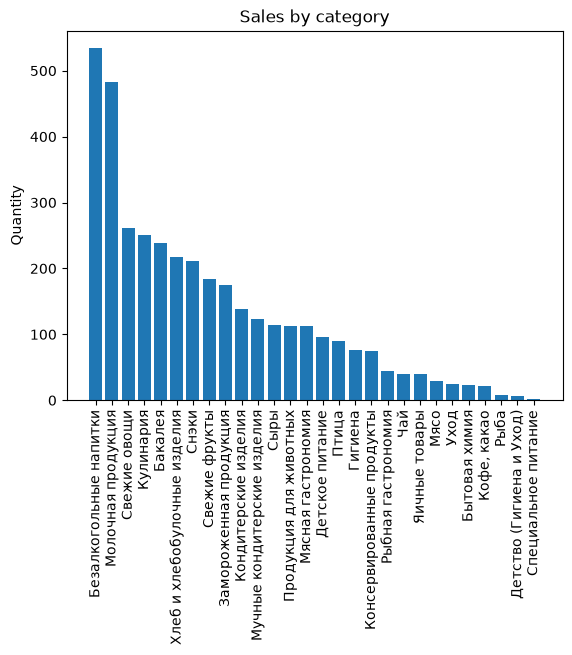

In [70]:
fig, ax = plt.subplots()

ax.bar(
    sales_by_category.index,
    sales_by_category['quantity']
)

ax.tick_params(axis="x", labelrotation=90)
ax.set_ylabel('Quantity')
ax.set_title('Sales by category')
plt.show()

In [53]:
pie_data = sales_by_category.copy()

small_share = pie_data['share'] < 4
other_share = pie_data.loc[small_share, ['share', 'quantity']].sum()

pie_data = pie_data.loc[~small_share]
pie_data.loc['Other', ['share', 'quantity']] = other_share

pie_data

,quantity,share
level1,,
Безалкогольные напитки,534.0,14.308682
Молочная продукция,483.0,12.942122
Свежие овощи,262.0,7.020364
Кулинария,250.0,6.698821
Бакалея,239.0,6.404073
Хлеб и хлебобулочные изделия,218.0,5.841372
Снэки,212.0,5.680600
Свежие фрукты,184.0,4.930332
Замороженная продукция,175.0,4.689175


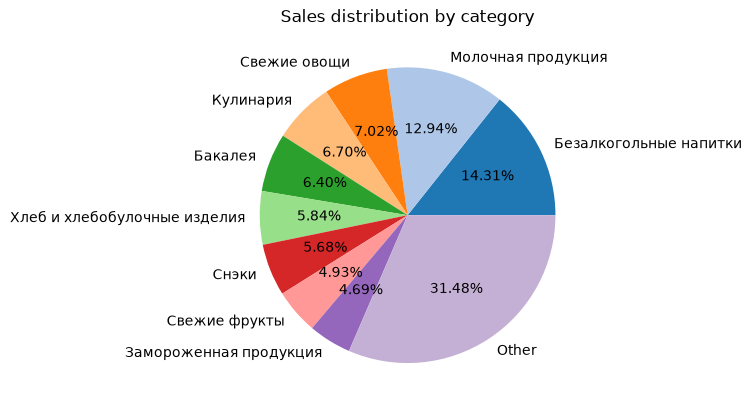

In [78]:
fig, ax = plt.subplots()

colors = plt.cm.tab20(range(len(pie_data)))

ax.pie(
    pie_data['share'],
    labels=pie_data.index,
    autopct=lambda pct: f"{pct:.2f}%",
    colors=colors
)

ax.set_title("Sales distribution by category")
plt.show()

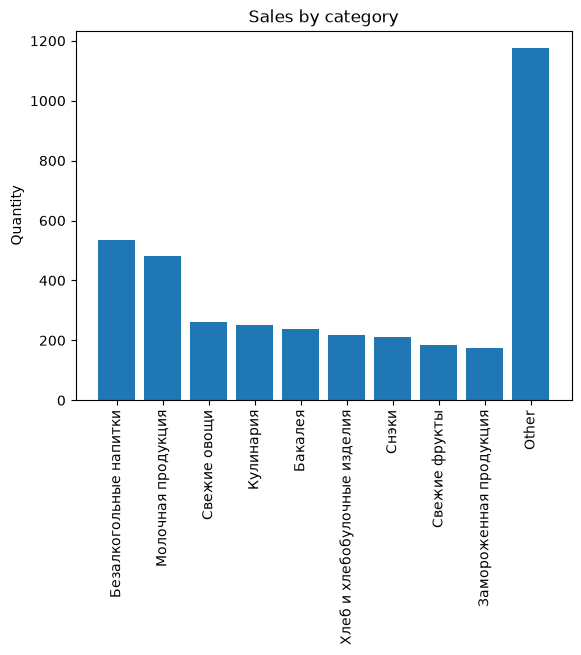

In [72]:
fig, ax = plt.subplots()

ax.bar(
    pie_data.index,
    pie_data['quantity']
)
ax.tick_params(axis="x", labelrotation=90)
ax.set_ylabel('Quantity')
ax.set_title('Sales by category')

plt.show()